Saving image1.jpg to image1.jpg
Image uploaded successfully: image1.jpg
Image size: (447, 447, 3)


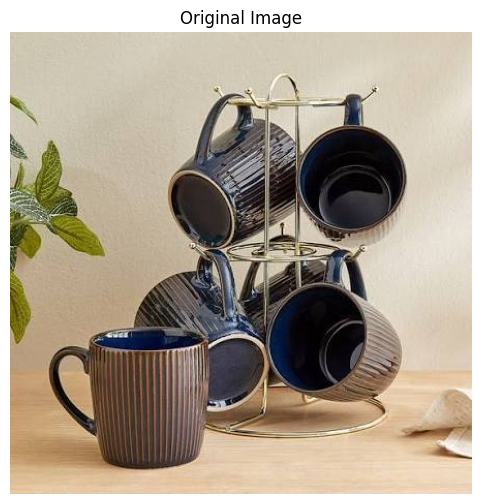

In [1]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image only once
uploaded = files.upload()

# Get uploaded filename
filename = next(iter(uploaded))

# Read image
img = cv2.imread(filename)

# Convert BGR to RGB for displaying with matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Image uploaded successfully:", filename)
print("Image size:", img.shape)

# Display original image
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

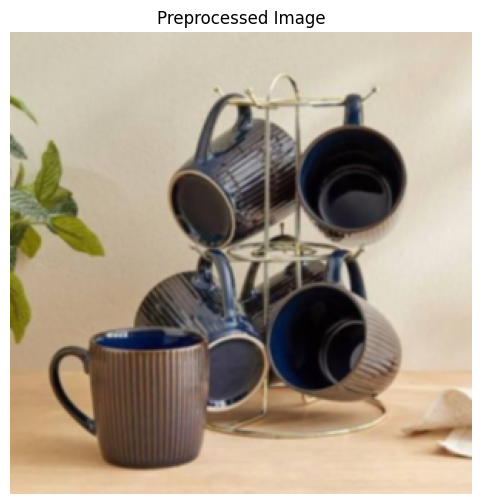

In [2]:
# Noise removal using Gaussian Blur
denoised = cv2.GaussianBlur(img, (5, 5), 0)

# Resize image
resized = cv2.resize(denoised, (300, 300))

# Normalize pixel values
normalized = cv2.normalize(resized, None, 0, 255, cv2.NORM_MINMAX)

# Convert for display
normalized_rgb = cv2.cvtColor(normalized, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(normalized_rgb)
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

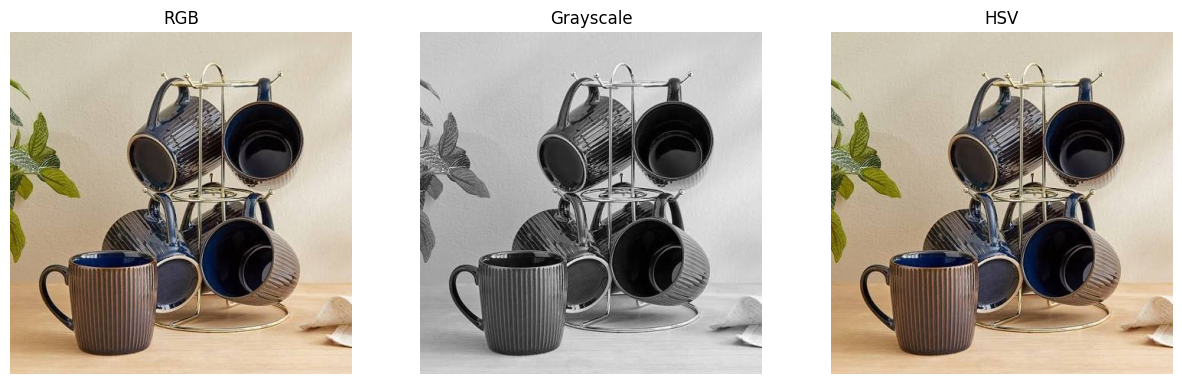

In [3]:
# Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Display
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
plt.title("HSV")
plt.axis("off")

plt.show()

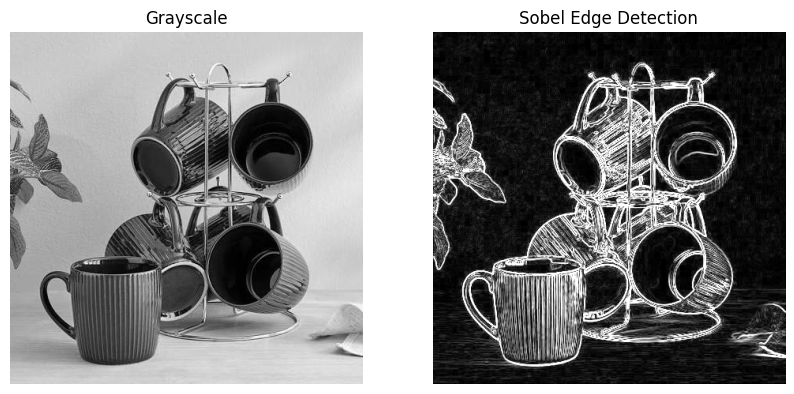

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Sobel X
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)

# Sobel Y
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

# Combine X and Y
sobel = cv2.magnitude(sobel_x, sobel_y)

# Convert to uint8
sobel = cv2.convertScaleAbs(sobel)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sobel, cmap="gray")
plt.title("Sobel Edge Detection")
plt.axis("off")

plt.show()

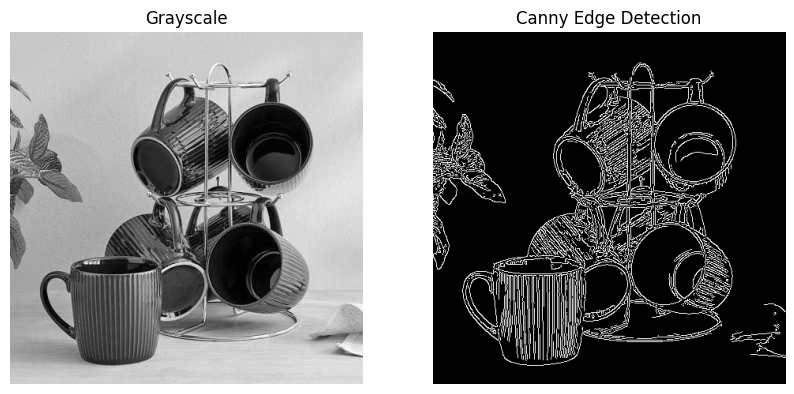

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Canny edge detection
edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.show()

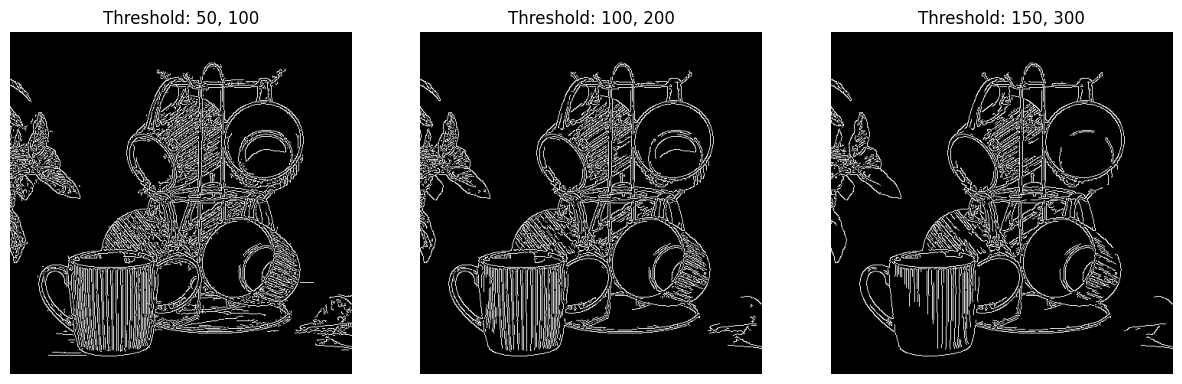

In [6]:
thresholds = [(50, 100), (100, 200), (150, 300)]

plt.figure(figsize=(15, 5))

for i, (low, high) in enumerate(thresholds):
    edges = cv2.Canny(gray, low, high)

    plt.subplot(1, 3, i + 1)
    plt.imshow(edges, cmap="gray")
    plt.title(f"Threshold: {low}, {high}")
    plt.axis("off")

plt.show()

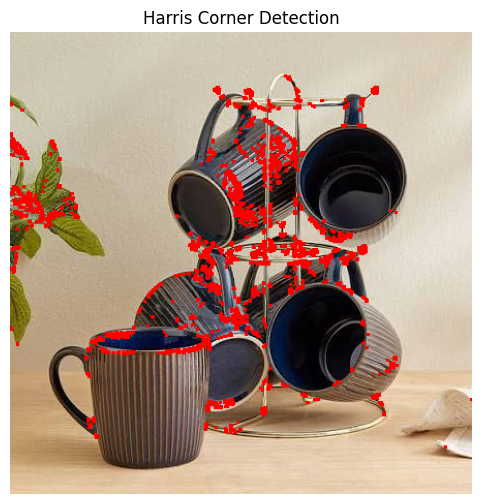

In [7]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Convert to float32
gray_float = np.float32(gray)

# Harris corner detection
corners = cv2.cornerHarris(gray_float, 2, 3, 0.04)

# Dilate corners
corners = cv2.dilate(corners, None)

# Mark corners
result = img_rgb.copy()
result[corners > 0.01 * corners.max()] = [255, 0, 0]

plt.figure(figsize=(8, 6))
plt.imshow(result)
plt.title("Harris Corner Detection")
plt.axis("off")
plt.show()

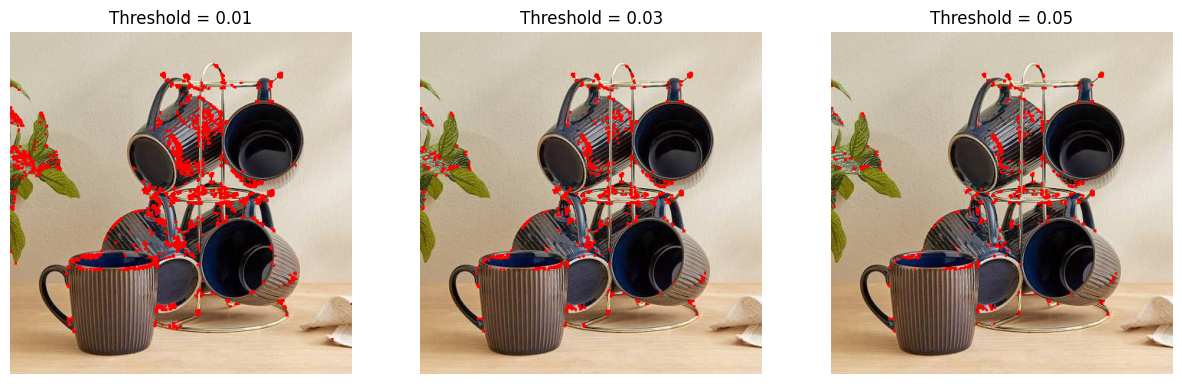

In [8]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_float = np.float32(gray)

corners = cv2.cornerHarris(gray_float, 2, 3, 0.04)
corners = cv2.dilate(corners, None)

thresholds = [0.01, 0.03, 0.05]

plt.figure(figsize=(15, 5))

for i, threshold in enumerate(thresholds):

    result = img_rgb.copy()

    result[corners > threshold * corners.max()] = [255, 0, 0]

    plt.subplot(1, 3, i + 1)
    plt.imshow(result)
    plt.title(f"Threshold = {threshold}")
    plt.axis("off")

plt.show()

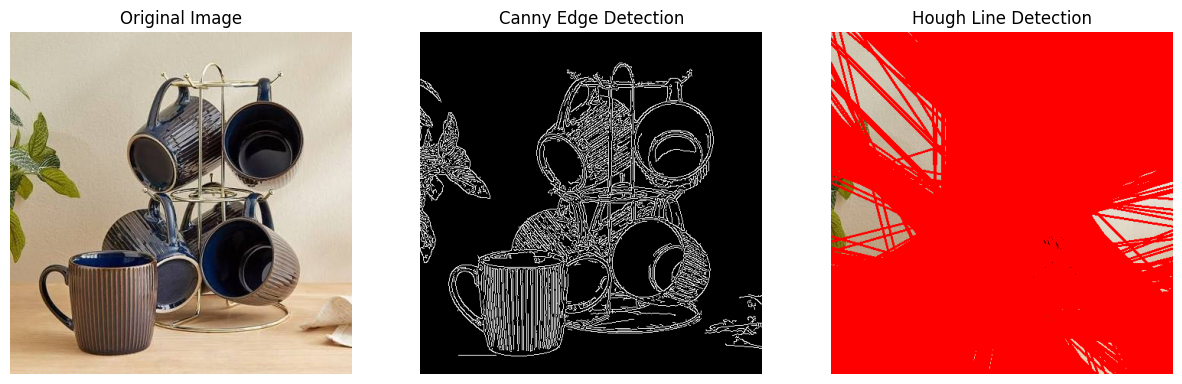

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect edges using Canny
edges = cv2.Canny(gray, 50, 150)

# Apply Standard Hough Transform
lines = cv2.HoughLines(edges, 1, np.pi / 180, 100)

# Create a copy of the original image
result = img.copy()

# Draw detected lines
if lines is not None:
    for line in lines:
        rho, theta = line[0]

        a = np.cos(theta)
        b = np.sin(theta)

        x0 = a * rho
        y0 = b * rho

        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))

        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv2.line(result, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Convert BGR to RGB for displaying
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result_rgb)
plt.title("Hough Line Detection")
plt.axis("off")

plt.show()

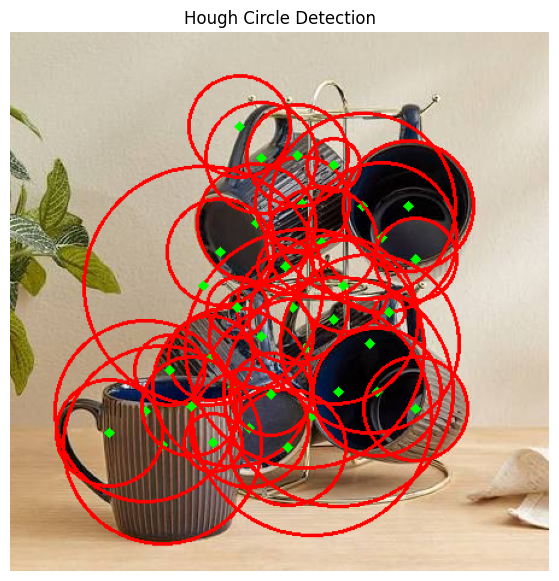

In [10]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Smooth image
gray_blur = cv2.medianBlur(gray, 5)

# Detect circles
circles = cv2.HoughCircles(
    gray_blur,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=30,
    param1=100,
    param2=30,
    minRadius=10,
    maxRadius=100
)

result = img_rgb.copy()

if circles is not None:

    circles = np.uint16(np.around(circles))

    for circle in circles[0]:
        x, y, r = circle

        cv2.circle(result, (x, y), r, (255, 0, 0), 2)
        cv2.circle(result, (x, y), 2, (0, 255, 0), 3)

plt.figure(figsize=(10, 7))
plt.imshow(result)
plt.title("Hough Circle Detection")
plt.axis("off")
plt.show()

Number of keypoints in Image 1: 804
Number of keypoints in Image 2: 1522


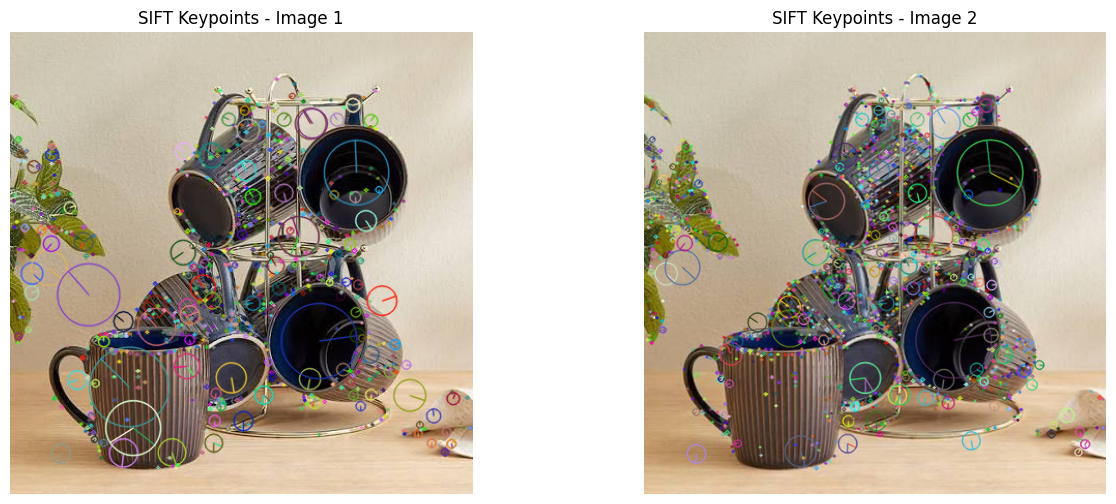

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Original image already uploaded
img1 = img.copy()

# Create a second image by resizing the original image
img2 = cv2.resize(img1, None, fx=1.2, fy=1.2)

# Convert both images to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)

print("Number of keypoints in Image 1:", len(keypoints1))
print("Number of keypoints in Image 2:", len(keypoints2))

# Draw keypoints
image1_keypoints = cv2.drawKeypoints(
    img1,
    keypoints1,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

image2_keypoints = cv2.drawKeypoints(
    img2,
    keypoints2,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Convert BGR to RGB
image1_keypoints = cv2.cvtColor(image1_keypoints, cv2.COLOR_BGR2RGB)
image2_keypoints = cv2.cvtColor(image2_keypoints, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(image1_keypoints)
plt.title("SIFT Keypoints - Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2_keypoints)
plt.title("SIFT Keypoints - Image 2")
plt.axis("off")

plt.show()

Total matches: 804
Good matches after ratio test: 530


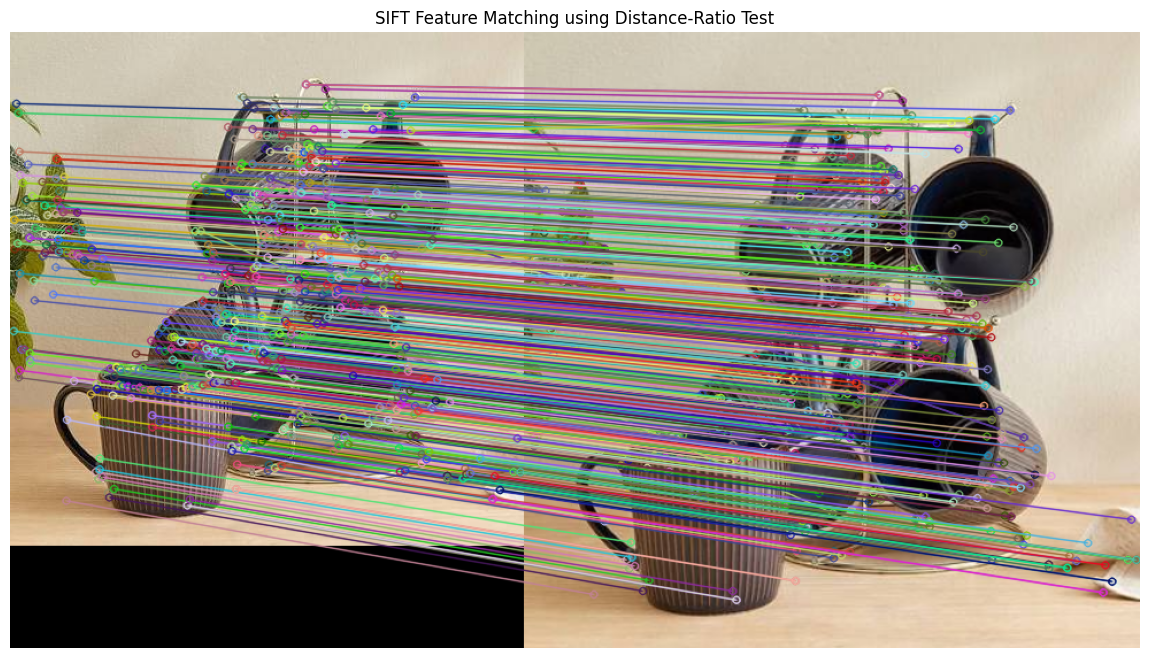

In [13]:
# Create BFMatcher
bf = cv2.BFMatcher()

# Find the two nearest matches for each descriptor
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# Apply Lowe's distance-ratio test
good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Total matches:", len(matches))
print("Good matches after ratio test:", len(good_matches))

# Draw good matches
matched_image = cv2.drawMatches(
    img1,
    keypoints1,
    img2,
    keypoints2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Convert BGR to RGB
matched_image = cv2.cvtColor(matched_image, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(16, 8))
plt.imshow(matched_image)
plt.title("SIFT Feature Matching using Distance-Ratio Test")
plt.axis("off")
plt.show()

Original dimensions: (100, 100)
Reduced dimensions: (100, 50)
Variance retained: 99.43 %


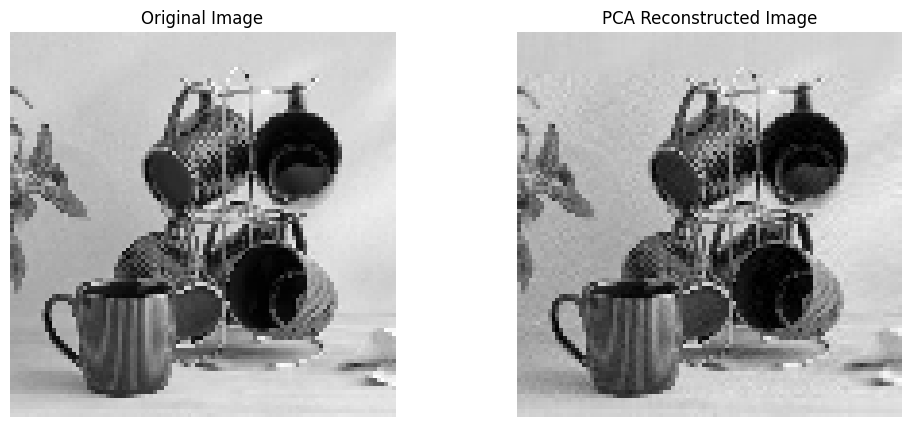

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Convert image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Resize image for easier PCA processing
gray_resized = cv2.resize(gray, (100, 100))

# Convert image into a matrix
data = gray_resized.astype(float)

# Apply PCA
pca = PCA(n_components=50)

reduced_data = pca.fit_transform(data)

# Reconstruct image from reduced components
reconstructed = pca.inverse_transform(reduced_data)

# Convert values to valid pixel range
reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)

# Calculate explained variance
variance = np.sum(pca.explained_variance_ratio_) * 100

print("Original dimensions:", data.shape)
print("Reduced dimensions:", reduced_data.shape)
print("Variance retained:", round(variance, 2), "%")

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_resized, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap="gray")
plt.title("PCA Reconstructed Image")
plt.axis("off")

plt.show()

Keypoints in Image 1: 746
Keypoints in Image 2: 879
Good matched keypoints: 593


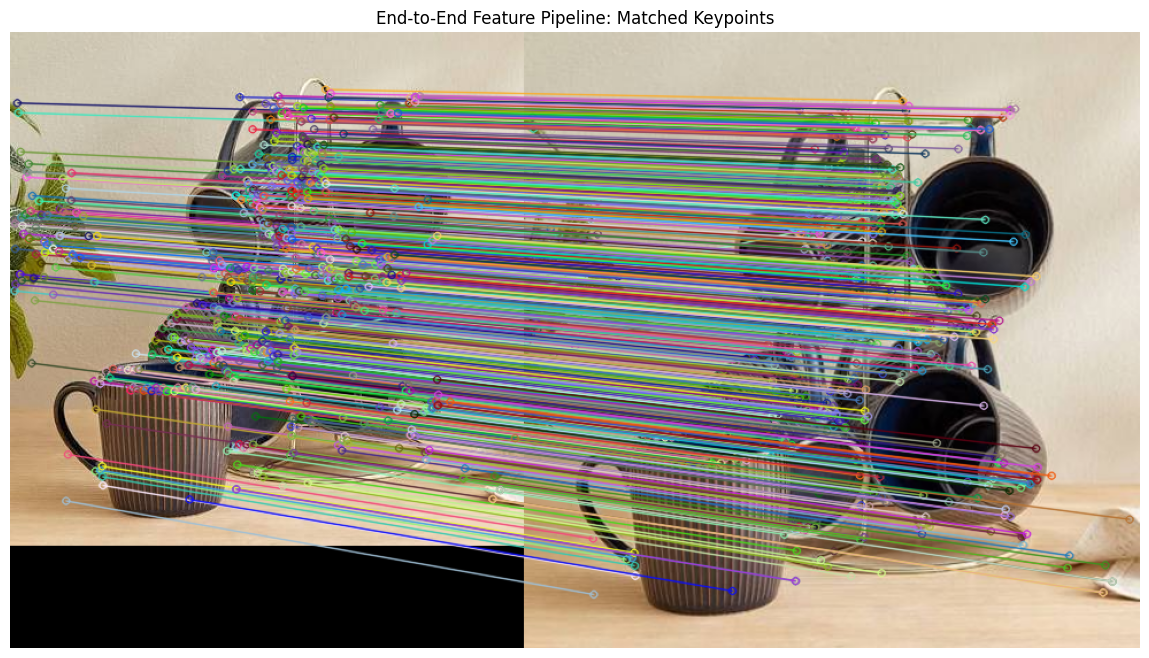

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# STEP 1: Original image
# --------------------------------------------------

img1 = img.copy()

# --------------------------------------------------
# STEP 2: Preprocessing
# --------------------------------------------------

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

# Remove noise
blur1 = cv2.GaussianBlur(gray1, (5, 5), 0)

# --------------------------------------------------
# STEP 3: Create second image
# --------------------------------------------------

img2 = cv2.resize(img1, None, fx=1.2, fy=1.2)

gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

blur2 = cv2.GaussianBlur(gray2, (5, 5), 0)

# --------------------------------------------------
# STEP 4: SIFT feature extraction
# --------------------------------------------------

sift = cv2.SIFT_create()

keypoints1, descriptors1 = sift.detectAndCompute(
    blur1, None
)

keypoints2, descriptors2 = sift.detectAndCompute(
    blur2, None
)

print("Keypoints in Image 1:", len(keypoints1))
print("Keypoints in Image 2:", len(keypoints2))

# --------------------------------------------------
# STEP 5: Feature matching
# --------------------------------------------------

bf = cv2.BFMatcher()

matches = bf.knnMatch(
    descriptors1,
    descriptors2,
    k=2
)

# --------------------------------------------------
# STEP 6: Distance-ratio test
# --------------------------------------------------

good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Good matched keypoints:", len(good_matches))

# --------------------------------------------------
# STEP 7: Draw matched keypoints
# --------------------------------------------------

matched_image = cv2.drawMatches(
    img1,
    keypoints1,
    img2,
    keypoints2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

matched_image = cv2.cvtColor(
    matched_image,
    cv2.COLOR_BGR2RGB
)

# --------------------------------------------------
# STEP 8: Display complete pipeline
# --------------------------------------------------

plt.figure(figsize=(16, 8))

plt.imshow(matched_image)
plt.title("End-to-End Feature Pipeline: Matched Keypoints")
plt.axis("off")

plt.show()